# Exercise 3: Neural networks in PyTorch

In this exercise you’ll implement small neural-network building blocks from scratch and use them to train a simple classifier.

You’ll cover:
- **Basic layers**: Linear, Embedding, Dropout
- **Normalization**: LayerNorm and RMSNorm
- **MLPs + residual**: composing layers into deeper networks
- **Classification**: generating a learnable dataset, implementing cross-entropy from logits, and writing a minimal training loop

As before: fill in all `TODO`s without changing function names or signatures.
Use small sanity checks and compare to PyTorch reference implementations when useful.

In [1]:
from __future__ import annotations

import torch
from torch import nn

## Basic layers

In this section you’ll implement a few core layers that appear everywhere:

### `Linear`
A fully-connected layer that follows nn.Linear conventions:  
`y = x @ Wᵀ + b`

Important details:
- Parameters should be registered as `nn.Parameter`
- Store weight as (out_features, in_features) like nn.Linear.
- The forward pass should support leading batch dimensions: `x` can be shape `(..., in_features)`

### `Embedding`
An embedding table maps integer ids to vectors:
- input: token ids `idx` of shape `(...,)`
- output: vectors of shape `(..., embedding_dim)`

This is essentially a learnable lookup table.

### `Dropout`
Dropout randomly zeroes activations during training to reduce overfitting.
Implementation details:
- Only active in `model.train()` mode
- In training: drop with probability `p` and scale the kept values by `1/(1-p)` so the expected value stays the same
- In eval: return the input unchanged

## Instructions
- Do not use PyTorch reference modules for the parts you implement (e.g. don’t call nn.Linear inside your Linear).
- You may use standard tensor ops that you learned before (matmul, sum, mean, rsqrt, indexing, etc.).
- Use a parameter initialization method of your choice. We recommend something like Xavier-uniform.


In [2]:
class Linear(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        self.weight = nn.Parameter(torch.empty((out_features, in_features)))
        if (bias):
            self.bias = nn.Parameter(torch.empty((out_features)))
        else:
            self.bias = None
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.weight)
        if self.bias is not None:
            fan_in = self.weight.size(1)
            bound = 1 / fan_in**0.5
            nn.init.uniform_(self.bias, -bound, bound)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., in_features)
        return: (..., out_features)
        """
        y = x @ self.weight.T
        if (self.bias is not None):
            y = y + self.bias
        return y

In [3]:
class Embedding(nn.Module):
    def __init__(self, num_embeddings: int, embedding_dim: int):
        super().__init__()
        # TODO: initialize
        #   An embedding table maps integer ids to vectors:
        # - input: token ids `idx` of shape `(...,)`
        # - output: vectors of shape `(..., embedding_dim)
        self.weight = nn.Parameter(
                torch.empty((num_embeddings, embedding_dim)),
            )
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.normal(self.weight)

    def forward(self, idx: torch.Tensor) -> torch.Tensor:
        """
        idx: (...,) int64
        return: (..., embedding_dim)
        """
        return self.weight[idx]

In [4]:
class Dropout(nn.Module):
    def __init__(self, p: float):
        super().__init__()
        self.p = p

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        In train mode: drop with prob p and scale by 1/(1-p).
        In eval mode: return x unchanged.
        """
        # TODO: implement without using nn.Dropout
        if self.training:
            scaling = 1/(1-self.p)
            mask = torch.rand_like(x) > self.p
            return x*mask*scaling
        else: 
            return x
   

## Normalization

Normalization layers help stabilize training by controlling activation statistics.

### LayerNorm
LayerNorm normalizes each example across its **feature dimension** (the last dimension):

- compute mean and variance over the last dimension
- normalize: `(x - mean) / sqrt(var + eps)`
- apply learnable per-feature scale and shift (`weight`, `bias`)

**In this exercise, assume `elementwise_affine=True` (always include `weight` and `bias`).**  
`weight` and `bias` each have shape `(D,)`.

LayerNorm is widely used in transformers because it does not depend on batch statistics.

### RMSNorm
RMSNorm is similar to LayerNorm but normalizes using only the root-mean-square:
- `x / sqrt(mean(x^2) + eps)` over the last dimension
- usually includes a learnable scale (`weight`)
- no mean subtraction

RMSNorm is popular in modern LLMs because it's faster.


In [5]:
class LayerNorm(nn.Module):
    def __init__(
        self, normalized_shape: int, eps: float = 1e-5, elementwise_affine: bool = True
    ):
        super().__init__()
        self.eps = eps
        self.normalized_shape = normalized_shape
        self.elementwise_affine = elementwise_affine

        if self.elementwise_affine:
            self.weight = nn.Parameter(torch.ones(normalized_shape))
            self.bias = nn.Parameter(torch.zeros(normalized_shape))
        else:
            self.register_parameter("weight", None)
            self.register_parameter("bias", None)
    

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Normalize over the last dimension.
        x: (..., D)
        """
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, unbiased=False, keepdim=True)  # match nn.LayerNor
        x = (x-mean)/torch.sqrt(var+self.eps)

        if (self.elementwise_affine):
            x = x*self.weight + self.bias

        return x

In [6]:
class RMSNorm(nn.Module):
    def __init__(self, normalized_shape: int, eps: float = 1e-8):
        super().__init__()
        self.eps = eps
        self.normalized_shape = normalized_shape
        self.weight = nn.Parameter(torch.ones(normalized_shape))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        RMSNorm: x / sqrt(mean(x^2) + eps) * weight
        over the last dimension.
        """
        rms = torch.sqrt(x.pow(2).mean(dim=1, keepdim=True)+ self.eps)
        x_norm = (x/rms)*self.weight
        return x_norm

## MLPs and residual networks

Now you’ll build larger networks by composing layers.

### MLP
An MLP is a stack of `depth` Linear layers with non-linear activations (use GELU) in between.
In this exercise you’ll support:
- configurable depth
- a hidden dimension
- optional LayerNorm between layers (a common stabilization trick)

A key skill is building networks using `nn.ModuleList` / `nn.Sequential` while keeping shapes consistent.

### Transformer-style FeedForward (FFN)
A transformer block contains a position-wise feedforward network:
- `D -> 4D -> D` (by default)
- activation is typically **GELU**

This is essentially an MLP applied independently at each token position.

### Residual wrapper
Residual connections are the simplest form of “skip connection”:
- output is `x + fn(x)`

They improve gradient flow and allow training deeper networks more reliably.

In [7]:
class MLP(nn.Module):
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        out_dim: int,
        depth: int,
        use_layernorm: bool = False,
    ):
        super().__init__()
        # TODO: build modules (list of Linear + activation)
        # Optionally insert LayerNorm between layers.
        self.in_dim = in_dim
        self.hidden_dim = hidden_dim
        self.out_dim = out_dim
        self.depth = depth
        self.use_layernorm = use_layernorm

        layers = []

        if depth == 1:
            layers.append(nn.Linear(in_dim, out_dim))
        else:
            layers.append(nn.Linear(in_dim, hidden_dim))
            for i in range(depth-2):
                layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Linear(hidden_dim, out_dim))

        self.layers = nn.ModuleList(layers)

        if self.use_layernorm:
            norms = []
            if depth == 1:
                norms.append(nn.LayerNorm(out_dim))
            else:
                norms.append(nn.LayerNorm(hidden_dim))
                for _ in range(depth - 2):
                    norms.append(nn.LayerNorm(hidden_dim))
                norms.append(nn.LayerNorm(out_dim))

            self.norms = nn.ModuleList(norms)
        else:
            self.norms = None

        self.act = nn.GELU()


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for i, layer in enumerate(self.layers):
            x = layer(x)

            if self.use_layernorm:
                x = self.norms[i](x)

            if i<self.depth-1:
                x = self.act(x)
        return x

In [8]:
class FeedForward(nn.Module):
    """
    Transformer-style FFN: D -> 4D -> D (default)
    """

    def __init__(self, d_model: int, d_ff: int | None = None):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        # TODO: create two Linear layers and choose an activation (GELU)

        self.lin1 = nn.Linear(d_model, d_ff)
        self.lin2 = nn.Linear(d_ff, d_model)
        self.act = nn.GELU() 

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.lin1(x)
        x = self.act(x)
        x = self.lin2(x)
        return x

In [9]:
class Residual(nn.Module):
    def __init__(self, fn: nn.Module):
        super().__init__()
        self.fn = fn
         

    def forward(self, x: torch.Tensor, *args, **kwargs) -> torch.Tensor:
        # TODO: return x + fn(x, ...)
        return x + self.fn(x)

## Classification problem

In this section you’ll put everything together in a minimal MNIST classification experiment.

You will:
1) download and load the MNIST dataset
2) implement cross-entropy from logits (stable, using log-softmax)
3) build a simple MLP-based classifier (flatten MNIST images first)
4) write a minimal training loop
5) report train loss curve and final accuracy

The goal here is not to reach state-of-the-art accuracy, but to understand the full pipeline:
data → model → logits → loss → gradients → parameter update.

### Model notes
- We want you to combine the MLP we implemented above with the classification head we define below into one model 

### MNIST notes
- MNIST images are `28×28` grayscale.
- After `ToTensor()`, each image has shape `(1, 28, 28)` and values in `[0, 1]`.
- For an MLP classifier, we flatten to a vector of length `784`.

## Deliverables
- Include a plot of your train loss curve in the video submission as well as a final accuracy. 
- **NOTE** Here we don't grade on model performance but we expect you to achieve at least 70% accuracy to confirm a correct model implementation.

In [10]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [11]:
transform = transforms.ToTensor()  # -> float32 in [0,1], shape (1, 28, 28)

train_ds = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="data", train=False, download=True, transform=transform)

# define the dataloaders
train_data_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_data_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

In [12]:
def cross_entropy_from_logits(
    logits: torch.Tensor,
    targets: torch.Tensor,
) -> torch.Tensor:
    """
    Compute mean cross-entropy loss from logits.

    logits: (B, C)
    targets: (B,) int64

    Requirements:
    - Use log-softmax for stability (do not use torch.nn.CrossEntropyLoss, we check this in the autograder).
    """
    # define and apply softmax on logits
    soft_max = nn.LogSoftmax(dim=1)
    logits_s_m = soft_max(logits)

    # compute loss per sample and return mean
    loss_per_sample = -logits_s_m[range(len(targets)), targets]
    return torch.mean(loss_per_sample)

In [13]:
class ClassificationHead(nn.Module):
    def __init__(self, d_in: int, num_classes: int):
        super().__init__()
        # flatten images (flattens all dimensions after 0)
        self.flatten = nn.Flatten()
        # linear network
        self.linear = nn.Linear(d_in, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.flatten(x)
        x = self.linear(x)
        return x

In [ ]:
def accuracy(model, loader):
    # eval mode
    model.eval()
    correct = total = 0

    # use the test data loader to evaluate the current accuracy of the model
    with torch.no_grad():
        for images, labels in loader:
            # predict on test images and save the predicted outputs
            outputs = model(images)
            predicted = torch.argmax(outputs, dim=1)
            # update total number of labels
            total += labels.size(0)
            # update correct number of labels
            correct += (predicted == labels).sum().item()
    return correct / total # returns current accuracy


In [ ]:
def train_classifier(
    model: nn.Module,
    train_data_loader: DataLoader,
    test_data_loader: DataLoader,
    lr: float,
    epochs: int,
    seed: int = 0,
) -> list[float]:
    """
    Minimal training loop for MNIST classification.

    Steps:
    - define optimizer
    - for each epoch:
        - sample minibatches
        - forward -> cross-entropy -> backward -> optimizer step
      - compute test accuracy at the end of each epoch
    - return list of training losses (one per update step)

    Requirements:
    - call model.train() during training and model.eval() during evaluation
    - do not use torch.nn.CrossEntropyLoss (use your cross_entropy_from_logits)
    """

    # define ADAM optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []

    for epoch in range(epochs):
        # training mode
        model.train()
        # variables to compute loss over epochs
        running_loss = 0.0 
        num_batches = 0

        # iterate over train_data_loader
        for images, y in train_data_loader:
            optimizer.zero_grad() # reset gradients
            outputs = model(images) # apply model (forward)
            loss = cross_entropy_from_logits(outputs, y) # compute loss (cross-entropy)
            loss.backward() # backward propagate
            optimizer.step() # optimizer step
            running_loss += loss.item() # update running loss for this epoch
            num_batches += 1 # update num_bataches for this epoch
        
        avg_epoch_loss = running_loss / num_batches # avg loss over this epoch
        losses.append(avg_epoch_loss)

        # Evaluation phase (per epoch)
        model.eval()
        test_acc = accuracy(model, test_data_loader) # test current accuracy
        print(f"Epoch:{epoch} avg_loss:{avg_epoch_loss:.4f} test_acc:{test_acc:.4f}")
    

    Plot_Active = False

    if (Plot_Active):
        import matplotlib.pyplot as plt

        plt.rcParams.update({
        "font.size": 14,
        "figure.dpi": 300,
        "axes.linewidth": 1.2,
        })
        
        epochs = range(1, len(losses) + 1)

        plt.figure(figsize=(6, 4))
        plt.plot(epochs, losses, marker='o', label='Training loss')
        plt.title('HW1 Ex3: MNIST training loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.grid(True, linestyle='--', alpha=0.4)
        plt.legend()
        plt.tight_layout()

        # Save as high-quality SVG
        plt.savefig("mnist_training_loss.svg", format="svg")

        plt.show()

Epoch:0 avg_loss:0.5428 test_acc:0.9102
Epoch:1 avg_loss:0.3230 test_acc:0.9175
Epoch:2 avg_loss:0.2952 test_acc:0.9227
Epoch:3 avg_loss:0.2817 test_acc:0.9245
Epoch:4 avg_loss:0.2740 test_acc:0.9246
Epoch:5 avg_loss:0.2679 test_acc:0.9255
Epoch:6 avg_loss:0.2635 test_acc:0.9268
Epoch:7 avg_loss:0.2600 test_acc:0.9249
Epoch:8 avg_loss:0.2574 test_acc:0.9268
Epoch:9 avg_loss:0.2547 test_acc:0.9280


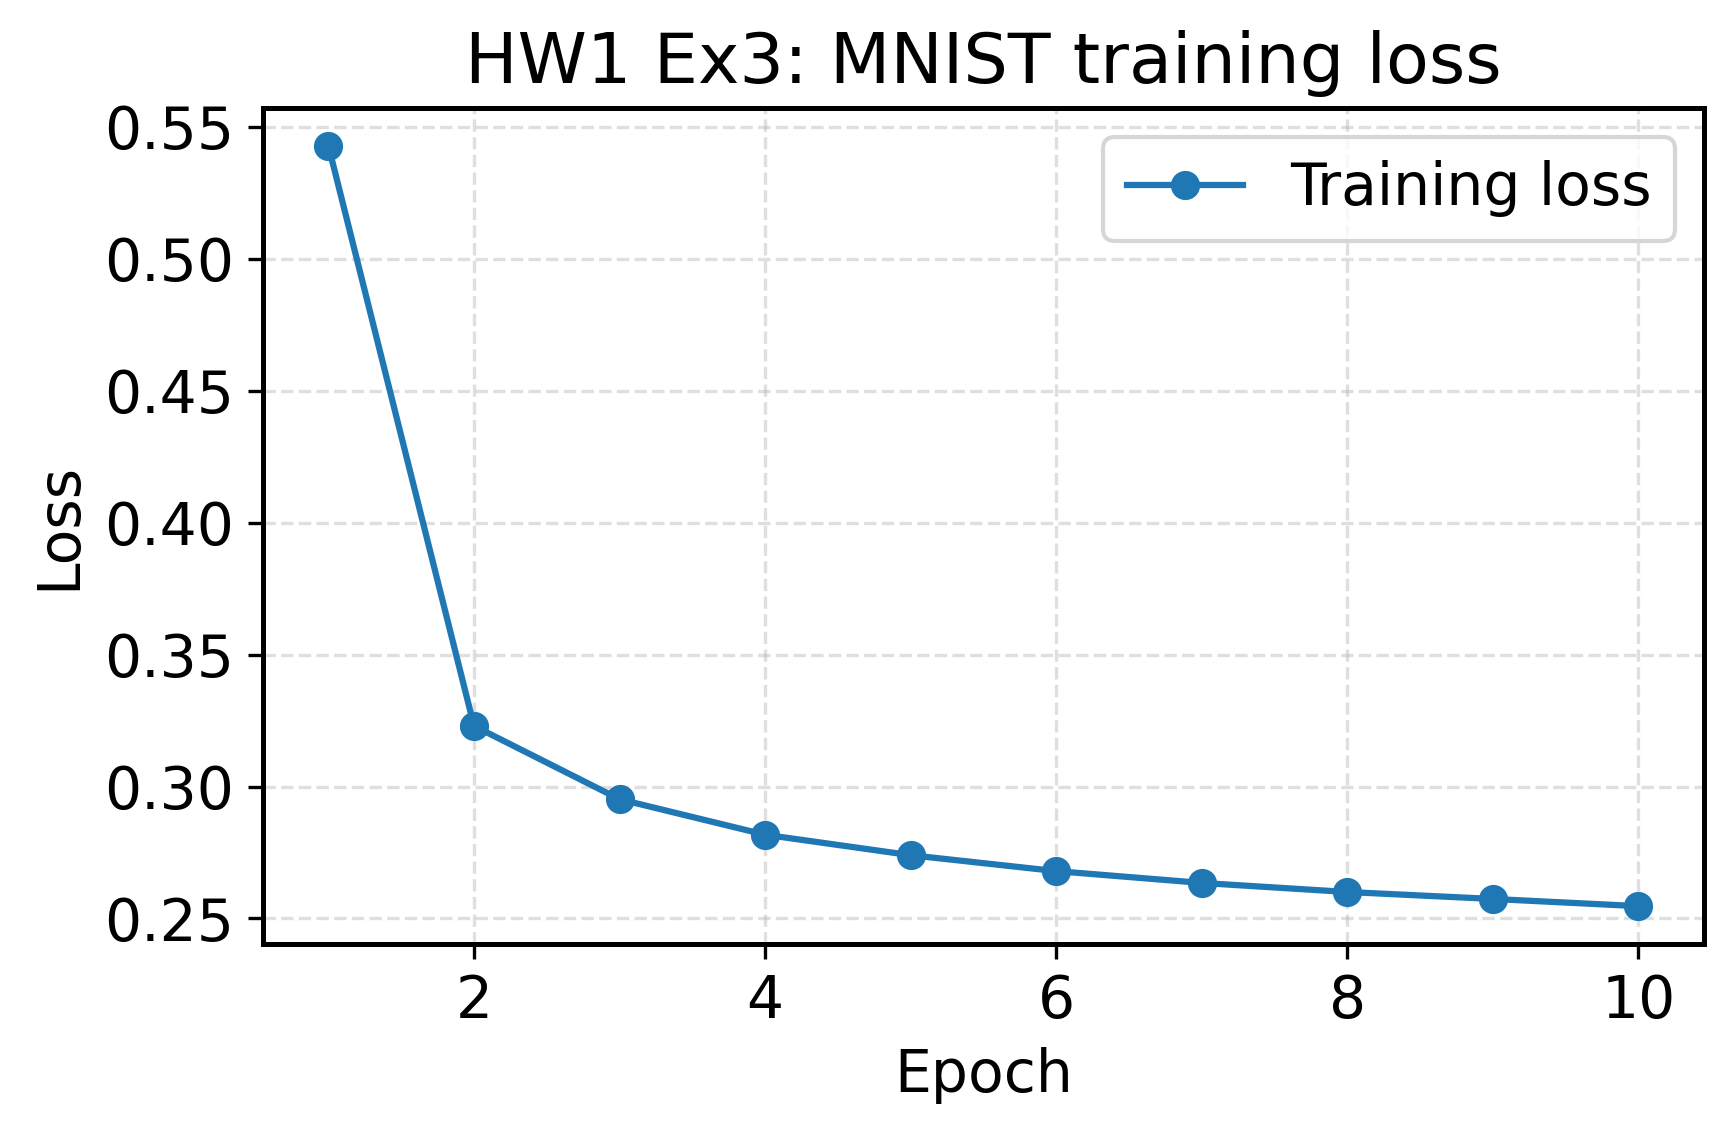

In [29]:
# define a classifier with (d_in: 28*28, num_classes: 10 -> given from task)
classifier = ClassificationHead(784,10)
# train the classifier, chose learning rate lr=0.001 (from trying out different ones/google search)
train_classifier(classifier, train_data_loader, test_data_loader, lr=0.001, epochs=10, seed=42)

In [30]:
# Final evaluation - one line!
final_accuracy = accuracy(classifier, test_data_loader)
print(f"Final test accuracy: {final_accuracy:.4f}")

Final test accuracy: 0.9280
